# Notebook 03: Baseline Models

This notebook loads the prepared training and testing datasets, trains Logistic Regression, Decision Tree, and Random Forest models, compares their performance, displays confusion matrices and ROC curves, and saves the results.


## 1. Import libraries


In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load prepared data


In [2]:
CURRENT_DIR = Path.cwd()

PROJECT_DIR = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "baseline_models"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

X_train = pd.read_pickle(
    DATA_DIR / "X_train_prepared.pkl"
)

X_test = pd.read_pickle(
    DATA_DIR / "X_test_prepared.pkl"
)

y_train = pd.read_pickle(
    DATA_DIR / "y_train.pkl"
)

y_test = pd.read_pickle(
    DATA_DIR / "y_test.pkl"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training shape: (3008, 35)
Testing shape: (752, 35)
Training target: (3008,)
Testing target: (752,)


## 3. Validate loaded data


In [3]:
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert X_train.shape[1] == X_test.shape[1]
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

print("Prepared feature count:", X_train.shape[1])

print("\nTraining target distribution:")
display(
    y_train.value_counts()
    .sort_index()
    .rename_axis("academic_risk_label")
    .to_frame("count")
)

print("Testing target distribution:")
display(
    y_test.value_counts()
    .sort_index()
    .rename_axis("academic_risk_label")
    .to_frame("count")
)


Prepared feature count: 35

Training target distribution:


,count
academic_risk_label,
0,2262
1,746


Testing target distribution:


,count
academic_risk_label,
0,565
1,187


## 4. Define baseline models


In [4]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

print("Baseline models created.")


Baseline models created.


## 5. Train and evaluate models


In [5]:
results = []
trained_models = {}
predictions_by_model = {}
probabilities_by_model = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    ).ravel()

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    })

    trained_models[model_name] = model
    predictions_by_model[model_name] = predictions
    probabilities_by_model[model_name] = probabilities

print("Training completed.")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training completed.


## 6. Compare model metrics


In [6]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["f1_score", "roc_auc", "recall"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    results_df.round(4)
)

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print("Best model based on F1 score:")
print(best_model_name)


,model,accuracy,precision,recall,f1_score,roc_auc,true_negatives,false_positives,false_negatives,true_positives
0,Random Forest,0.8670,0.7101,0.7861,0.7462,0.9150,505,60,40,147
1,Logistic Regression,0.8311,0.6190,0.8342,0.7107,0.9046,469,96,31,156
2,Decision Tree,0.8285,0.6218,0.7914,0.6965,0.8806,475,90,39,148


Best model based on F1 score:
Random Forest


## 7. Plot metric comparison


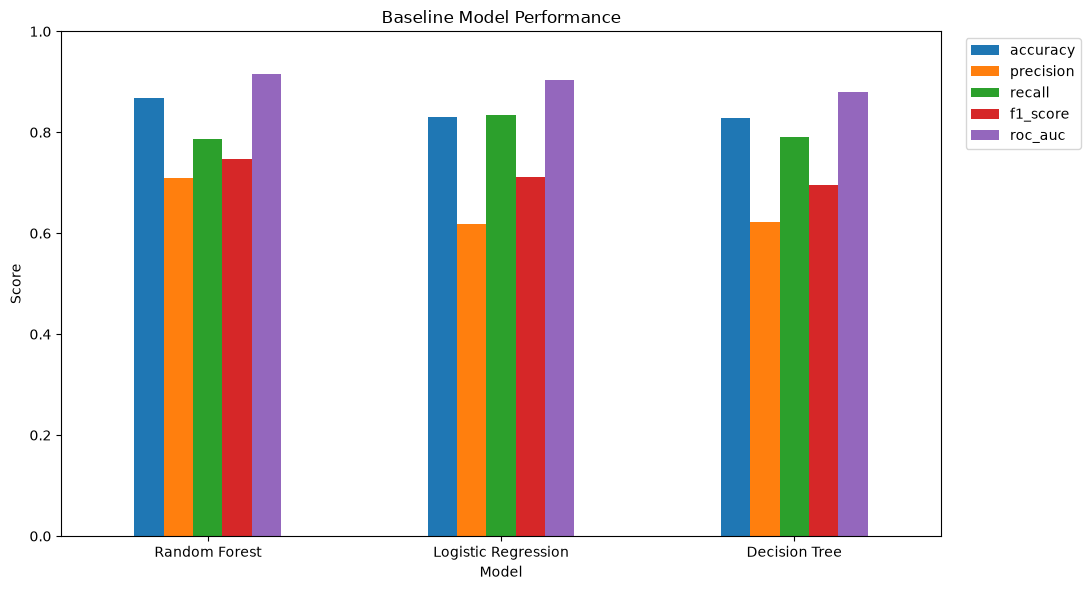

In [7]:
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]

plot_data = (
    results_df[
        ["model"] + metric_columns
    ]
    .set_index("model")
)

plot_data.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title("Baseline Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()


## 8. Display confusion matrices


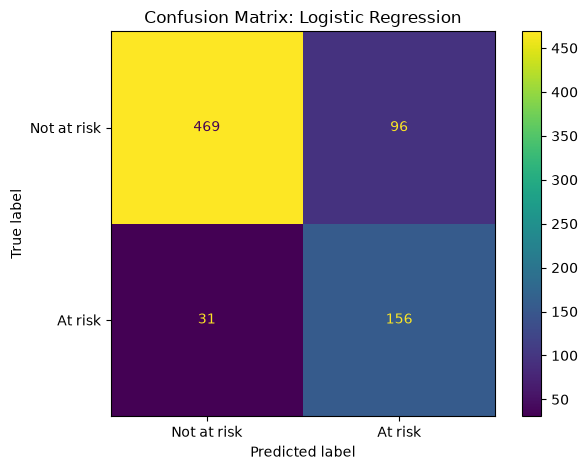

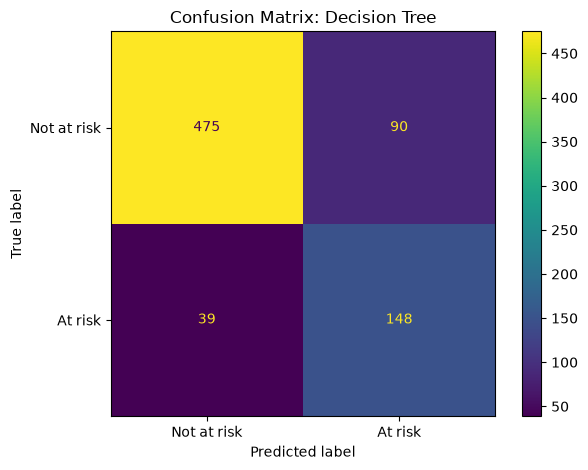

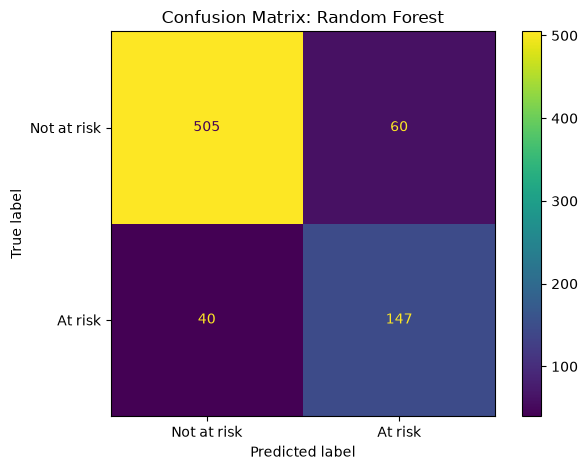

In [8]:
for model_name, model in trained_models.items():

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        labels=[0, 1],
        display_labels=[
            "Not at risk",
            "At risk",
        ],
        values_format="d",
    )

    plt.title(
        f"Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()


## 9. Display ROC curves


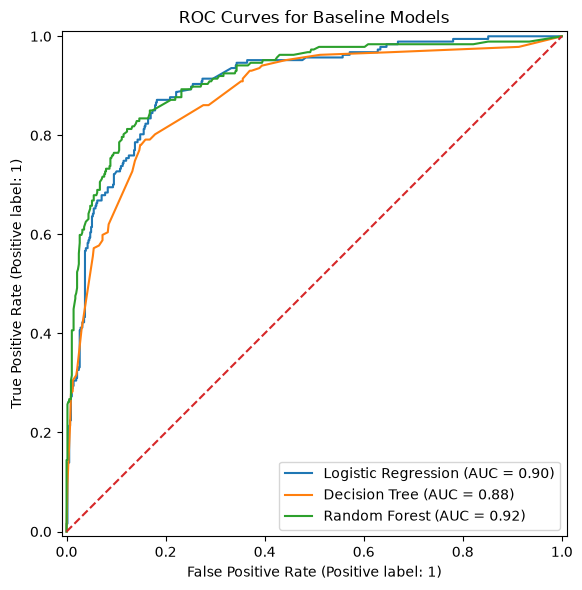

In [9]:
figure, axis = plt.subplots(
    figsize=(8, 6)
)

for model_name, model in trained_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=axis,
    )

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

axis.set_title(
    "ROC Curves for Baseline Models"
)

plt.tight_layout()
plt.show()


## 10. Show classification reports


In [10]:
for model_name in trained_models:

    print(f"Classification report: {model_name}")

    print(
        classification_report(
            y_test,
            predictions_by_model[model_name],
            target_names=[
                "Not at risk",
                "At risk",
            ],
            digits=4,
            zero_division=0,
        )
    )


Classification report: Logistic Regression
              precision    recall  f1-score   support

 Not at risk     0.9380    0.8301    0.8808       565
     At risk     0.6190    0.8342    0.7107       187

    accuracy                         0.8311       752
   macro avg     0.7785    0.8322    0.7957       752
weighted avg     0.8587    0.8311    0.8385       752

Classification report: Decision Tree
              precision    recall  f1-score   support

 Not at risk     0.9241    0.8407    0.8804       565
     At risk     0.6218    0.7914    0.6965       187

    accuracy                         0.8285       752
   macro avg     0.7730    0.8161    0.7885       752
weighted avg     0.8490    0.8285    0.8347       752

Classification report: Random Forest
              precision    recall  f1-score   support

 Not at risk     0.9266    0.8938    0.9099       565
     At risk     0.7101    0.7861    0.7462       187

    accuracy                         0.8670       752
   macro av

## 11. Review best model feature rankings


,feature,value,absolute_value
0,previous_cgpa_ordinal,0.0873,0.0873
1,repeated_course_count_current,0.0813,0.0813
2,previous_failed_course_count,0.0764,0.0764
3,previous_term_gpa_ordinal,0.0739,0.0739
4,attendance_rate,0.0574,0.0574
5,registered_credits,0.0548,0.0548
6,total_course_event_clicks,0.0525,0.0525
7,absence_count,0.0504,0.0504
8,registered_course_count,0.0383,0.0383
9,year_level_4,0.0373,0.0373


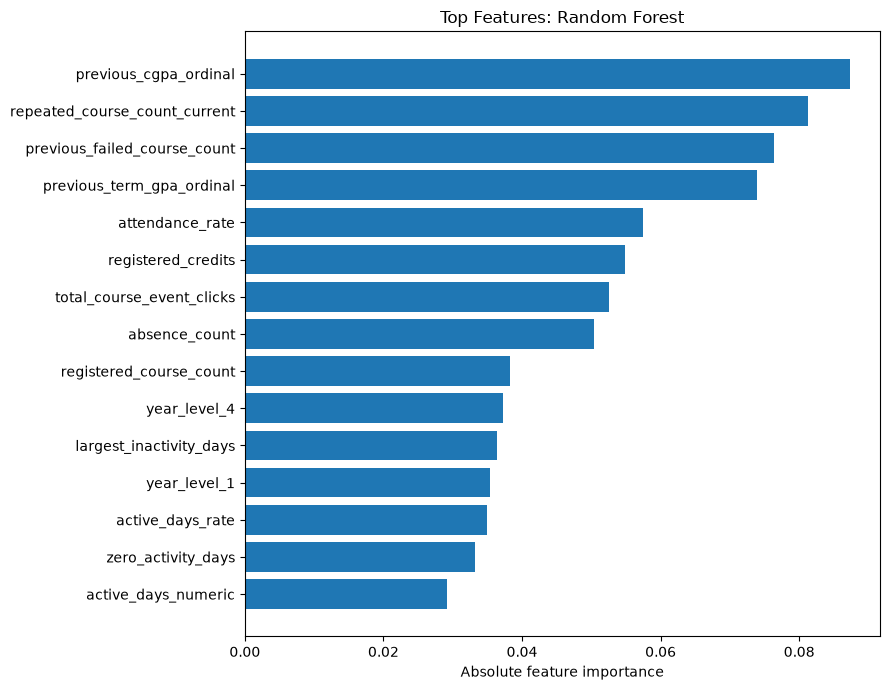

In [11]:
if hasattr(
    best_model,
    "feature_importances_",
):

    importance_values = (
        best_model.feature_importances_
    )

    importance_label = (
        "Feature importance"
    )

elif hasattr(
    best_model,
    "coef_",
):

    importance_values = (
        best_model.coef_[0]
    )

    importance_label = (
        "Model coefficient"
    )

else:

    importance_values = None
    importance_label = None


if importance_values is not None:

    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "value": importance_values,
        "absolute_value": np.abs(
            importance_values
        ),
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            "absolute_value",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(
        feature_importance_df
        .head(20)
        .round(4)
    )

    top_features = (
        feature_importance_df
        .head(15)
        .sort_values(
            "absolute_value"
        )
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.barh(
        top_features["feature"],
        top_features["absolute_value"],
    )

    plt.title(
        f"Top Features: {best_model_name}"
    )

    plt.xlabel(
        f"Absolute {importance_label.lower()}"
    )

    plt.tight_layout()
    plt.show()


## 12. Save model outputs


In [12]:
results_df.to_csv(
    RESULTS_DIR
    / "baseline_model_results.csv",
    index=False,
)

for model_name, model in trained_models.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    joblib.dump(
        model,
        RESULTS_DIR
        / f"{safe_name}.joblib",
    )

prediction_output = pd.DataFrame(
    index=X_test.index
)

prediction_output["actual_label"] = y_test

for model_name in trained_models:

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    prediction_output[
        f"{safe_name}_prediction"
    ] = predictions_by_model[
        model_name
    ]

    prediction_output[
        f"{safe_name}_probability"
    ] = probabilities_by_model[
        model_name
    ]

prediction_output.to_csv(
    RESULTS_DIR
    / "baseline_test_predictions.csv",
    index=True,
)

joblib.dump(
    best_model,
    RESULTS_DIR
    / "best_baseline_model.joblib",
)

with open(
    RESULTS_DIR
    / "best_model_name.txt",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        str(best_model_name)
    )

if "feature_importance_df" in globals():

    feature_importance_df.to_csv(
        RESULTS_DIR
        / "best_model_feature_importance.csv",
        index=False,
    )

print("Results saved to:")
print(RESULTS_DIR)


Results saved to:
c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\baseline_models


## Notebook 03 Summary

This notebook trained and evaluated three baseline models for early academic risk prediction. The models were compared using accuracy, precision, recall, F1 score, ROC AUC, confusion matrices, and classification reports. The best baseline model was selected primarily using F1 score, while recall remained important because it measures the proportion of at risk students correctly identified.
